## testing the models on unseen videos

In [1]:
pip install imageio[ffmpeg]

In [2]:
# rgb i3d pretrained model
!gdown "1t9aOdBR8XOMX4fqyjnDxWzM5b-o79yTG"

# i3d.py function for i3d feature extraction
!gdown "1b6bfkvrTZephMu8O1Rh2usWGYlNqUr4X"

Downloading...
From: https://drive.google.com/uc?id=1t9aOdBR8XOMX4fqyjnDxWzM5b-o79yTG
To: /content/rgb_imagenet.pt
100% 50.9M/50.9M [00:01<00:00, 47.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1b6bfkvrTZephMu8O1Rh2usWGYlNqUr4X
From (redirected): https://drive.google.com/uc?id=1b6bfkvrTZephMu8O1Rh2usWGYlNqUr4X&confirm=t&uuid=1ad87cfb-baad-42fa-a8ce-7b0920c5514d
To: /content/pytorch_i3d.py
100% 13.8k/13.8k [00:00<00:00, 29.5MB/s]


In [1]:
# Cell 1: Initialization, Function Definitions, and Model Loading (RUN ONCE)
import os
import cv2
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
from pytorch_i3d import InceptionI3d
from tensorflow.keras.models import load_model
from tqdm.notebook import tqdm
import subprocess
import tempfile
import shutil
from IPython.display import clear_output, Video, display
import warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ===== CONFIGURATION & THRESHOLDS (Aligned with Streamlit) =====
PROBABILITY_THRESHOLD = 0.90
PERCENT_SEQUENCES_THRESHOLD = 0.058 # 5.8%

# ===== Setup Device and I3D Loaders =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

def load_i3d_feature_extractor():
    i3d = InceptionI3d(400, in_channels=3)
    try:
        i3d.load_state_dict(torch.load('rgb_imagenet.pt', map_location=device), strict=False)
    except FileNotFoundError:
        print("❌ Error: rgb_imagenet.pt not found. Check the path.")
        return None
    i3d = i3d.to(device)
    i3d.eval()
    return i3d

# ===== Utility Functions =====
def video_to_tensor(pic):
    return torch.from_numpy(pic.transpose([3, 0, 1, 2]))

def segment_frames(frames, seq_length=64, overlap=8):
    step = seq_length - overlap
    return [np.array(frames[i:i + seq_length], dtype=np.float32) for i in range(0, len(frames) - seq_length + 1, step)]

def load_all_models(model_paths):
    print("🔄 Loading classification models...")
    models = {}
    for name, path in model_paths.items():
        try:
            models[name] = load_model(path)
        except Exception:
            print(f"⚠️ Warning: Could not load Keras model {path}. Skipping.")

    if not models:
        print("❌ Error: No classification models loaded.")
        return None

    # Warm-up the models
    dummy_input = np.zeros((1, 7, 1, 1, 1024), dtype=np.float32)
    for model in models.values():
        model.predict(dummy_input, verbose=0)

    print("✅ Models loaded:", ", ".join(models.keys()))
    return models

def ensure_30fps_video(video_path):
    """Downsamples video to 30 FPS if needed. Returns (path, temp_dir_if_created)"""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    if fps <= 30.01:
        return video_path, None

    temp_dir = tempfile.mkdtemp()
    new_video_path = os.path.join(temp_dir, "converted_30fps.mp4")

    cmd = ["ffmpeg", "-y", "-i", video_path, "-r", "30", "-loglevel", "error", new_video_path]
    subprocess.run(cmd, check=True)
    print(f"✅ Video converted from {fps:.1f} FPS to 30 FPS.")
    return new_video_path, temp_dir

def get_message(prob):
    if prob < 0.5:
        return "Normal activity detected"
    elif prob < 0.7:
        return "Minor irregularities observed"
    elif prob < 0.9:
        return "Potential anomaly — monitor activity"
    else:
        return "High-confidence anomaly — immediate review needed"

MESSAGE_COLORS = {
    "Normal activity detected": (0, 255, 0),
    "Minor irregularities observed": (0, 255, 255),
    "Potential anomaly — monitor activity": (0, 165, 255),
    "High-confidence anomaly — immediate review needed": (0, 0, 255)
}

# ===== Plotting Function =====
def plot_video_predictions(ensemble_preds, video_name, probability_threshold, required_count):
    """Generates a Matplotlib plot of sequence-level anomaly scores."""

    high_conf_count = np.sum(ensemble_preds >= probability_threshold)
    pred_label_str = 'Anomaly' if high_conf_count >= required_count else 'Normal'

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ensemble_preds, marker='o', linestyle='-', color='b', label='Sequence Probability')
    ax.axhline(y=probability_threshold, color='r', linestyle='--', label=f'Prob. Threshold ({probability_threshold:.2f})')

    high_conf_indices = np.where(ensemble_preds >= probability_threshold)[0]
    ax.scatter(high_conf_indices, ensemble_preds[high_conf_indices], color='red', s=100, zorder=5,
               label=f'Above Threshold ({high_conf_count} seqs)')

    plot_title = f"Video: {video_name} | Final Pred: {pred_label_str}\n"
    plot_title += f"Anomalous Sequences: {high_conf_count} / {len(ensemble_preds)} (Needed: {required_count})"
    ax.set_title(plot_title, fontsize=12)
    ax.set_xlabel("Sequence Index")
    ax.set_ylabel("Anomaly Probability Score")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ===== Two-Pass Main Analysis Function =====
def analyze_and_annotate_video(original_video_path, models, i3d, seq_length=64, overlap=8):

    clear_output(wait=True) # Clear previous results before starting new analysis
    print(f"--- Starting Analysis for: {os.path.basename(original_video_path)} ---")

    # 1. Setup paths and ensure FPS
    temp_output_dir = tempfile.mkdtemp()
    converted_temp_dir = None

    try:
        video_path, converted_temp_dir = ensure_30fps_video(original_video_path)
    except Exception as e:
        print(f"❌ Video Preparation Failed: {e}")
        return

    # --- PASS 1: Feature Extraction and Batch Prediction ---
    print("\n--- PASS 1: Feature Extraction and Batch Prediction ---")

    # Read all frames and preprocess
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_list = []

    print(f"🔄 Reading and preprocessing {total_frames} frames...")
    for _ in tqdm(range(total_frames), desc="Reading Frames"):
        ret, frame = cap.read()
        if not ret: break

        f = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (224, 224))
        f = f / 255.0 * 2 - 1
        frames_list.append(f)
    cap.release()

    if len(frames_list) < seq_length:
        print(f"❌ Error: Not enough frames ({len(frames_list)}) for minimum sequence length ({seq_length}).")
        if converted_temp_dir: shutil.rmtree(converted_temp_dir, ignore_errors=True)
        return

    sequences = segment_frames(frames_list, seq_length=seq_length, overlap=overlap)

    # Extract I3D features for all sequences in a loop
    all_i3d_features = []
    print(f"🔄 Extracting I3D features for {len(sequences)} sequences...")
    with torch.no_grad():
        for seq in tqdm(sequences, desc="I3D Feature Extraction"):
            seq_tensor = video_to_tensor(seq).unsqueeze(0).to(device)
            features = i3d.extract_features(seq_tensor).squeeze(0).permute(1, 2, 3, 0).cpu().numpy()
            all_i3d_features.append(features)

    all_i3d_features = np.array(all_i3d_features).reshape(-1, 7, 1, 1, 1024)

    # Batch Predict
    print("🔄 Running batch predictions...")
    all_preds_list = [model.predict(all_i3d_features, verbose=0).squeeze() for model in models.values()]
    ensemble_scores = np.mean(all_preds_list, axis=0)
    print(f"✅ Batch prediction complete. Got {len(ensemble_scores)} anomaly scores.")

    # --- PASS 2: Annotation, Video Generation, and Output ---
    print("\n--- PASS 2: Annotation and Output Generation ---")

    # Re-read video for annotation
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    extended_height = int(height * 1.18)
    font_scale = height / 720

    annotated_video_path = os.path.join(temp_output_dir, "annotated_video.mp4")
    writer = imageio.get_writer(annotated_video_path, fps=fps, codec='libx264', macro_block_size=16)

    frames_per_segment_step = seq_length - overlap

    print("🔄 Annotating video frames...")
    for frame_idx in tqdm(range(total_frames), desc="Annotating Frames"):
        ret, frame = cap.read()
        if not ret: break

        # Map frame to score index
        seq_idx = int(frame_idx / frames_per_segment_step)
        score_idx = min(seq_idx, len(ensemble_scores) - 1)
        prob = ensemble_scores[score_idx] if len(ensemble_scores) > 0 else 0.0

        # Draw overlay
        message_text = get_message(prob)
        font_color = MESSAGE_COLORS[message_text]
        overlay_text = f"Anomaly Score: {prob * 100:.1f}%"

        pad_height = int(np.ceil(extended_height / 16) * 16)
        new_frame = np.zeros((pad_height, width, 3), dtype=np.uint8)
        new_frame[:height] = frame

        cv2.putText(new_frame, overlay_text, (3, height + int(30 * font_scale)),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_color, 1, cv2.LINE_AA)
        cv2.putText(new_frame, message_text, (3, height + int(70 * font_scale)),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_color, 1, cv2.LINE_AA)

        new_frame_rgb = cv2.cvtColor(new_frame, cv2.COLOR_BGR2RGB)
        writer.append_data(new_frame_rgb)

    cap.release()
    writer.close()

    # --- Final Evaluation and Plot ---
    num_high_scores = sum(score >= PROBABILITY_THRESHOLD for score in ensemble_scores)
    required_count = max(1, int(len(ensemble_scores) * PERCENT_SEQUENCES_THRESHOLD))
    final_label = "Anomaly" if num_high_scores >= required_count else "Normal"

    print("\n--- FINAL RESULTS ---")
    print(f"🎬 Video: {os.path.basename(original_video_path)}")
    print(f"🌟 Final Prediction: {final_label}")
    print(f"📈 High-Confidence Segments: {num_high_scores} / {len(ensemble_scores)} (Required: {required_count})")

    print("\n📊 Plotting Anomaly Scores...")
    plot_video_predictions(ensemble_scores, os.path.basename(original_video_path),
                           PROBABILITY_THRESHOLD, required_count)

    print("\n🎞️ Displaying Annotated Video...")
    display(Video(annotated_video_path, embed=True, width=800))

    # --- Cleanup ---
    print("\n🧹 Cleaning temporary files and memory...")
    if converted_temp_dir: shutil.rmtree(converted_temp_dir, ignore_errors=True)
    shutil.rmtree(temp_output_dir, ignore_errors=True)
    gc.collect()
    torch.cuda.empty_cache()

# --- Load Models Once ---
i3d = load_i3d_feature_extractor()

model_paths = {
    "mean": "mean.keras",
    "max": "max.keras",
    "cnn": "cnn.keras",
    "lstm": "lstm.keras",
    "gru": "gru.keras"
}
models = load_all_models(model_paths)

✅ Using device: cpu
🔄 Loading classification models...


✅ Models loaded: mean, max, cnn, lstm, gru


#### Normal videos

--- Starting Analysis for: Normal_Videos012_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 2340 frames...


Reading Frames:   0%|          | 0/2340 [00:00<?, ?it/s]

🔄 Extracting I3D features for 41 sequences...


I3D Feature Extraction:   0%|          | 0/41 [00:00<?, ?it/s]

🔄 Running batch predictions...


✅ Batch prediction complete. Got 41 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/2340 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Normal_Videos012_x264.mp4
🌟 Final Prediction: Normal
📈 High-Confidence Segments: 0 / 41 (Required: 2)

📊 Plotting Anomaly Scores...


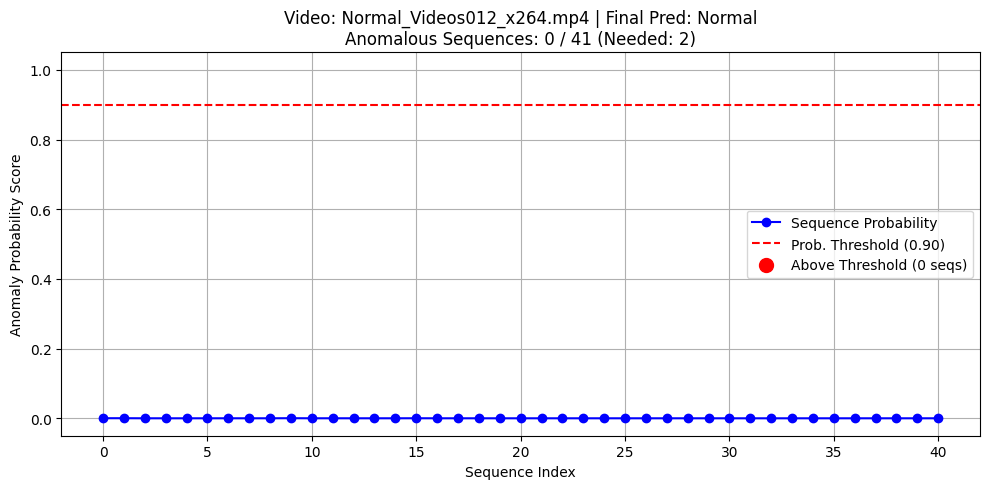


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [6]:
video_path = "/content/Normal_Videos012_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Normal_Videos020_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 485 frames...


Reading Frames:   0%|          | 0/485 [00:00<?, ?it/s]

🔄 Extracting I3D features for 8 sequences...


I3D Feature Extraction:   0%|          | 0/8 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 8 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/485 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Normal_Videos020_x264.mp4
🌟 Final Prediction: Normal
📈 High-Confidence Segments: 0 / 8 (Required: 1)

📊 Plotting Anomaly Scores...


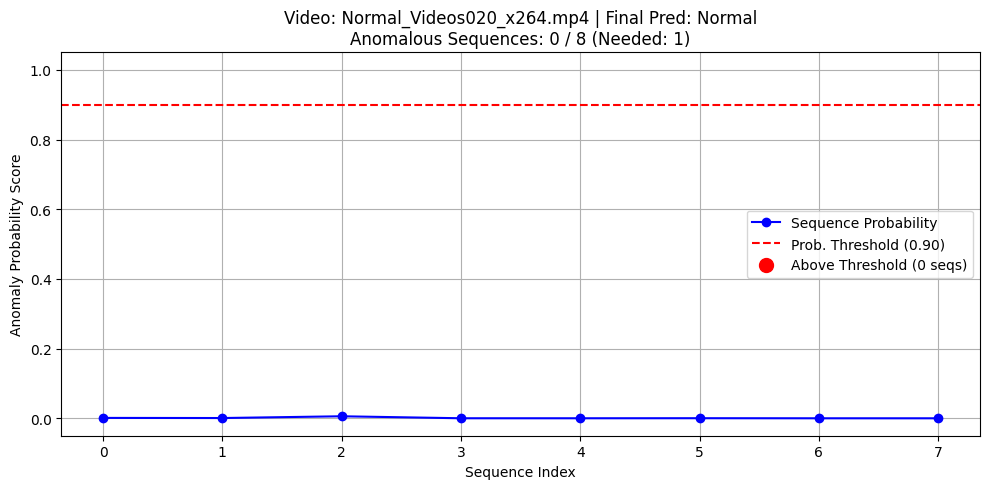


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [7]:
video_path = "/content/Normal_Videos020_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Normal_Videos030_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 4427 frames...


Reading Frames:   0%|          | 0/4427 [00:00<?, ?it/s]

🔄 Extracting I3D features for 78 sequences...


I3D Feature Extraction:   0%|          | 0/78 [00:00<?, ?it/s]

🔄 Running batch predictions...


✅ Batch prediction complete. Got 78 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/4427 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Normal_Videos030_x264.mp4
🌟 Final Prediction: Normal
📈 High-Confidence Segments: 0 / 78 (Required: 4)

📊 Plotting Anomaly Scores...


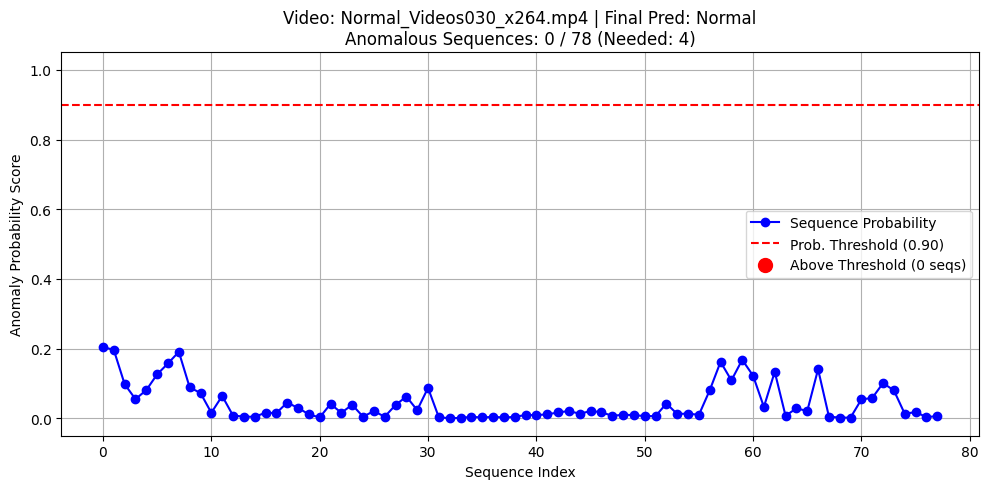


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [2]:
video_path = "/content/Normal_Videos030_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Normal_Videos036_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 1323 frames...


Reading Frames:   0%|          | 0/1323 [00:00<?, ?it/s]

🔄 Extracting I3D features for 23 sequences...


I3D Feature Extraction:   0%|          | 0/23 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 23 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/1323 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Normal_Videos036_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 7 / 23 (Required: 1)

📊 Plotting Anomaly Scores...


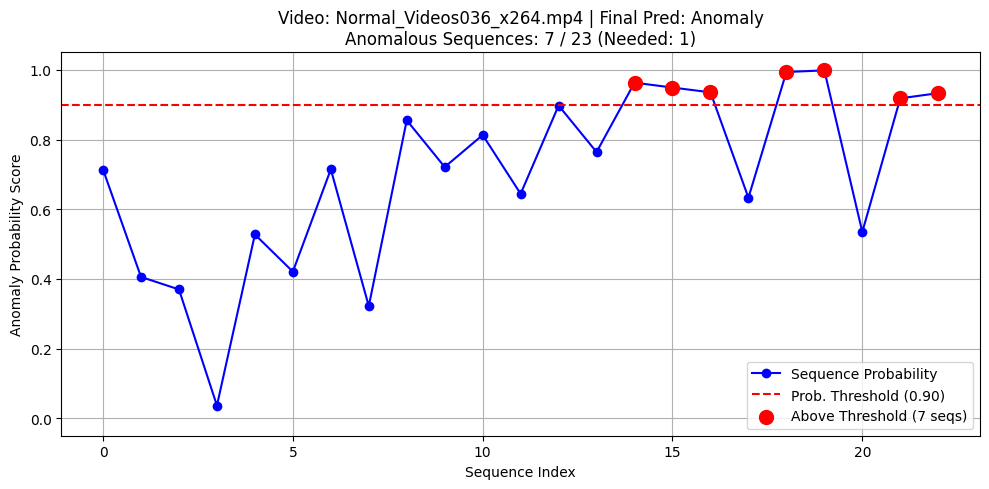


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [3]:
video_path = "/content/Normal_Videos036_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

##### anomaly videos

--- Starting Analysis for: Arrest015_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 976 frames...


Reading Frames:   0%|          | 0/976 [00:00<?, ?it/s]

🔄 Extracting I3D features for 17 sequences...


I3D Feature Extraction:   0%|          | 0/17 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 17 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/976 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Arrest015_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 6 / 17 (Required: 1)

📊 Plotting Anomaly Scores...


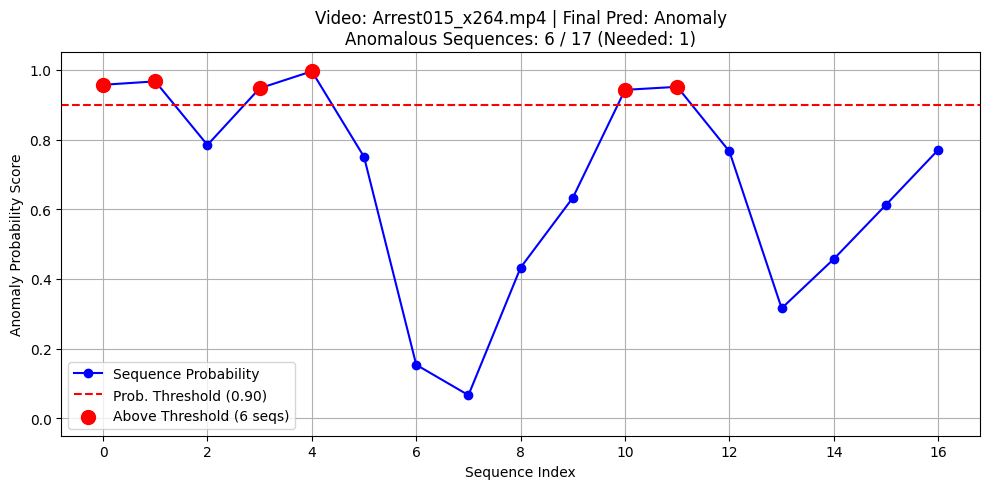


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [4]:
video_path = "/content/Arrest015_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Arrest040_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 1774 frames...


Reading Frames:   0%|          | 0/1774 [00:00<?, ?it/s]

🔄 Extracting I3D features for 31 sequences...


I3D Feature Extraction:   0%|          | 0/31 [00:00<?, ?it/s]

🔄 Running batch predictions...


✅ Batch prediction complete. Got 31 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/1774 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Arrest040_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 7 / 31 (Required: 1)

📊 Plotting Anomaly Scores...


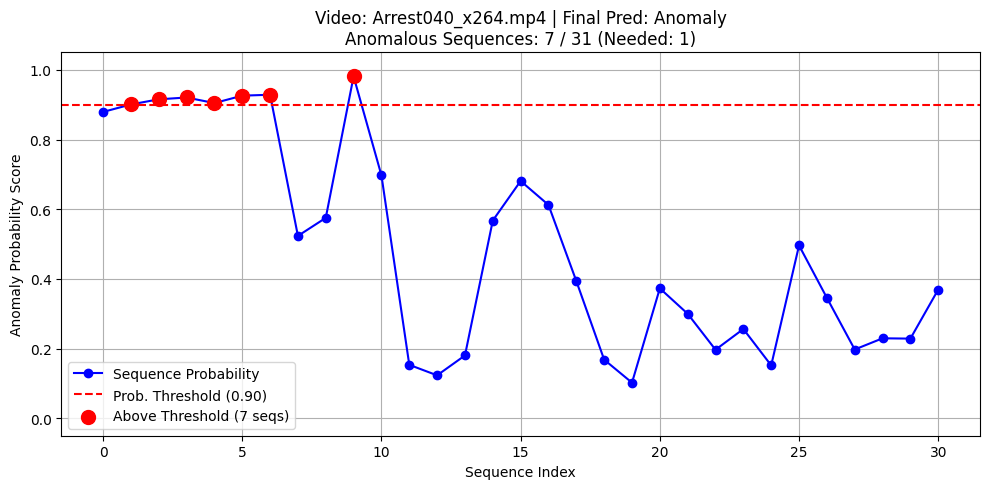


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [2]:
video_path = "/content/Arrest040_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Arson027_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 2697 frames...


Reading Frames:   0%|          | 0/2697 [00:00<?, ?it/s]

🔄 Extracting I3D features for 48 sequences...


I3D Feature Extraction:   0%|          | 0/48 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 48 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/2697 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Arson027_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 28 / 48 (Required: 2)

📊 Plotting Anomaly Scores...


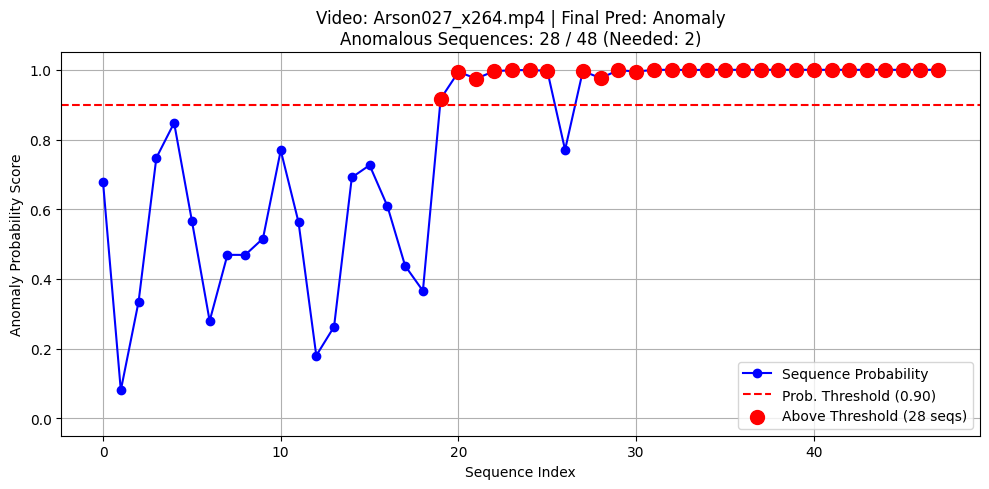


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [3]:
video_path = "/content/Arson027_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Arson038_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 737 frames...


Reading Frames:   0%|          | 0/737 [00:00<?, ?it/s]

🔄 Extracting I3D features for 13 sequences...


I3D Feature Extraction:   0%|          | 0/13 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 13 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/737 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Arson038_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 12 / 13 (Required: 1)

📊 Plotting Anomaly Scores...


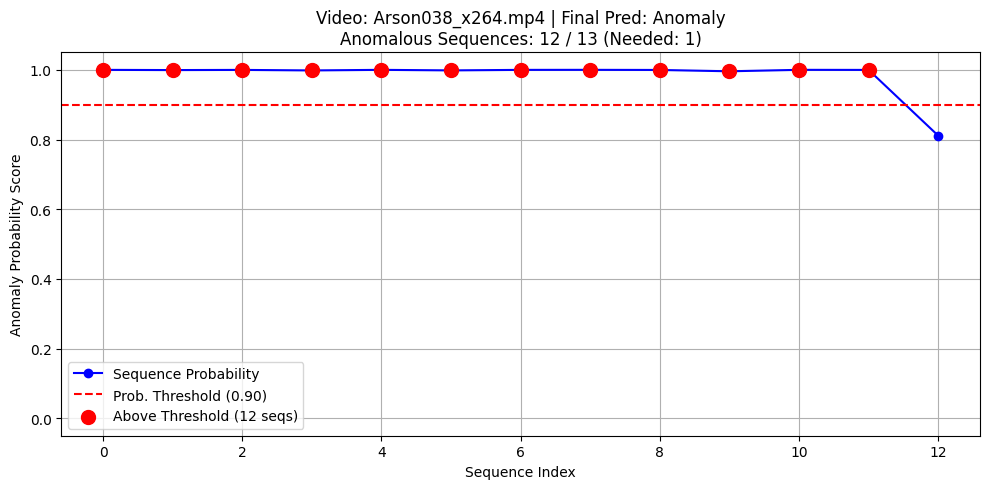


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [4]:
video_path = "/content/Arson038_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)

--- Starting Analysis for: Arson040_x264.mp4 ---

--- PASS 1: Feature Extraction and Batch Prediction ---
🔄 Reading and preprocessing 2835 frames...


Reading Frames:   0%|          | 0/2835 [00:00<?, ?it/s]

🔄 Extracting I3D features for 50 sequences...


I3D Feature Extraction:   0%|          | 0/50 [00:00<?, ?it/s]

🔄 Running batch predictions...
✅ Batch prediction complete. Got 50 anomaly scores.

--- PASS 2: Annotation and Output Generation ---
🔄 Annotating video frames...


Annotating Frames:   0%|          | 0/2835 [00:00<?, ?it/s]


--- FINAL RESULTS ---
🎬 Video: Arson040_x264.mp4
🌟 Final Prediction: Anomaly
📈 High-Confidence Segments: 42 / 50 (Required: 2)

📊 Plotting Anomaly Scores...


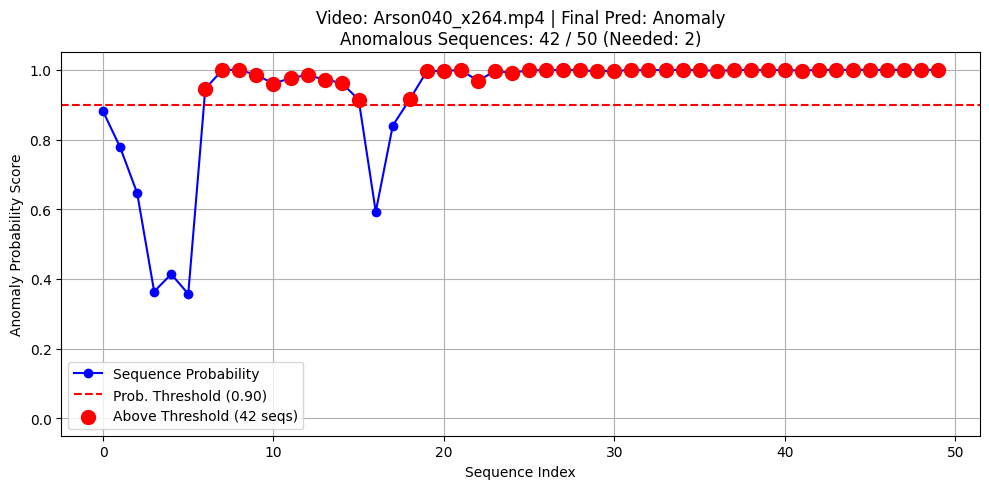


🎞️ Displaying Annotated Video...



🧹 Cleaning temporary files and memory...


In [5]:
video_path = "/content/Arson040_x264.mp4"
analyze_and_annotate_video(video_path, models,i3d)